# Digitdeck · Entregable M1 — Fine-tuning de encoder para ranking de relevancia

**Tópicos Especiales y Aplicaciones en IA** · Universidad EAFIT · SI4006 · Semestre 2026-2

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

**Equipo:** Maximiliano Bustamante · Valeria Frances Hornung · Sebastián Castaño · Alejandro Posada

**Repositorio:** [AlejandroSPosada/Topicos_IA_Proyecto_Digitdeck](https://github.com/AlejandroSPosada/Topicos_IA_Proyecto_Digitdeck)

---

Este notebook documenta el trabajo del equipo para el Módulo 1 del curso: selección y
justificación del modelo base, construcción del dataset ESCI en español, fine-tuning de un
**encoder** (`intfloat/multilingual-e5-small`) con una cabeza de clasificación binaria, y
evaluación comparativa contra los baselines definidos en el `README.md` del proyecto
(BM25 y E5-small congelado), con nDCG@10 como métrica primaria.

> **Decisión técnica de M1 (ver `README.md`):** se descarta el enfoque de fine-tuning causal
> sobre un LLM decoder. La tarea de M1 es asignar un score de relevancia a un par
> `(consulta, product_title)`, y eso es exactamente lo que resuelve un encoder con cabeza de
> clasificación — más liviano, más rápido de entrenar en una T4, y directamente evaluable con
> métricas de ranking (nDCG@10, MRR, Recall@10).

> **Requisito:** activar GPU antes de ejecutar.
> `Runtime → Change runtime type → T4 GPU`
> Sin GPU, el entrenamiento y la evaluación de las secciones 3 y 4 tardarán mucho más.

> **Nota sobre resultados:** este notebook implementa el pipeline completo y deja las celdas
> listas para ejecutar. Las secciones de lectura de resultados (§4.9, §4.10) se completan
> **después** de correrlo, con los números reales — no se rellenan con cifras inventadas.


## 0 · Entorno de trabajo

In [30]:
# Instalación del ecosistema Hugging Face + BM25. ~1-2 min la primera vez.
# Si Colab pide RESTART RUNTIME, reinicia y vuelve a ejecutar desde esta celda.
!pip install -q transformers datasets accelerate evaluate sentence-transformers rank_bm25 2>/dev/null
print("Librerías instaladas.")

Librerías instaladas.


In [31]:
# Registro del entorno de entrenamiento para garantizar reproducibilidad (criterio 3).
import importlib.metadata as meta
import sys, torch, random, numpy as np

SEMILLA = 42  # semilla global del proyecto — se reutiliza en todas las secciones

def fijar_semilla(seed: int = SEMILLA):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

fijar_semilla(SEMILLA)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=== Entorno de entrenamiento ===")
print(f"Python      : {sys.version.split()[0]}")
print(f"Dispositivo : {DEVICE}", end="")
print(f" | {torch.cuda.get_device_name(0)}" if DEVICE == "cuda" else " [AVISO: sin GPU activa — secciones 3 y 4 serán lentas]")
print(f"Semilla     : {SEMILLA}")
print()
for pkg in ["torch", "transformers", "datasets", "accelerate", "evaluate", "sentence_transformers", "rank_bm25"]:
    try:
        print(f"  {pkg:<22} {meta.version(pkg)}")
    except meta.PackageNotFoundError:
        print(f"  {pkg:<22} FALTA")

=== Entorno de entrenamiento ===
Python      : 3.12.13
Dispositivo : cuda | Tesla T4
Semilla     : 42

  torch                  2.11.0+cu128
  transformers           5.13.1
  datasets               4.0.0
  accelerate             1.14.0
  evaluate               0.4.6
  sentence_transformers  5.6.0
  rank_bm25              0.2.2


**Pendiente manual (TODO §0, no scriptable):**
- Abrir [`S04_Lab_Fine_tuning_SOLUCION.ipynb`](../../Clases/M1/S04_Lab_Fine_tuning_SOLUCION.ipynb)
  en Colab y verificar que corre de punta a punta con GPU T4 antes de continuar.
- Crear cuenta en [Hugging Face](https://huggingface.co) y generar un token de acceso si el
  equipo va a subir el modelo entrenado al Hub (§3.10, opcional).


In [32]:
# Login opcional a Hugging Face Hub — solo necesario si se va a ejecutar la celda
# opcional de §3.10 (subir el modelo fine-tuned al Hub). Se puede saltar sin problema.
SUBIR_A_HUB = False  # cambiar a True y ejecutar login() si el equipo decide subir el modelo

if SUBIR_A_HUB:
    from huggingface_hub import login
    login()
else:
    print("SUBIR_A_HUB = False — celda de login omitida.")

SUBIR_A_HUB = False — celda de login omitida.


---

# 1 · Selección y justificación del modelo base

## 1.1 · Variantes a evaluar

Siguiendo la decisión técnica documentada en el `README.md`, el equipo no compara modelos
causales entre sí: compara **estrategias de scoring de relevancia** bajo el mismo split ESCI
y el mismo presupuesto de GPU T4. El candidato eficiente es `intfloat/multilingual-e5-small`,
un encoder multilingüe (~117 M parámetros), evaluado contra un techo léxico (BM25) y contra
su propia versión sin fine-tuning (congelada) — esto último para aislar el efecto del
fine-tuning del efecto del pre-entrenamiento.

| Variante | Entrenamiento | Métrica primaria | Guardrails |
|---|---|---|---|
| BM25 | Ninguno | nDCG@10 | latencia, tamaño de índice |
| E5-small congelado | Ninguno | nDCG@10 | memoria, p95 |
| **E5-small ajustado** ← candidato | Pares/grados ESCI es | nDCG@10 | MRR, Recall@10, memoria, p95 |
| E5-base ajustado *(opcional)* | Mismo split; mayor presupuesto | nDCG@10 | mejora por costo |

**Por qué esta lista y no otra:**
- **BM25** es el techo léxico clásico de recuperación — sin él, la tabla de resultados no
  tiene punto de referencia no neuronal.
- **E5-small congelado** separa el efecto del encoder pre-entrenado del efecto del
  fine-tuning: si ya supera a BM25 sin haber visto un solo ejemplo de ESCI, el argumento de
  invertir en fine-tuning se fortalece; si no lo supera, es un hallazgo honesto que también
  se reporta (§4.9–4.10).
- **E5-small ajustado** es el candidato real de M1: multilingüe, visto en clase (S01),
  ~117 M parámetros — dentro del presupuesto T4 con margen amplio para batch size y `fp16`.
- **E5-base ajustado** es una ablación de tamaño (opcional, ~278 M parámetros): permite leer
  si el costo adicional de cómputo se traduce en mejora de nDCG@10.
- **BGE-M3 + reranker** queda descartado de M1: su arquitectura de dos etapas (retriever +
  cross-encoder) no permite comparación bajo las mismas condiciones que las demás variantes,
  y su p95 en T4 es prohibitiva para el caso de uso. Candidato natural para M2/M3.

## 1.2 · Atributos registrados desde las model cards oficiales

In [33]:
# Atributos de cada variante encoder, tomados de las model cards oficiales en Hugging Face.
# BM25 no tiene "model card": es un algoritmo léxico, no una red neuronal — se documenta aparte.
VARIANTES_ENCODER = [
    {
        "id":        "intfloat/multilingual-e5-small",
        "rol":       "Candidato M1 (congelado y ajustado)",
        "params_m":  118,
        "disco_mb":  470,
        "familia":   "E5 (XLM-RoBERTa base multilingüe)",
        "idiomas":   "100 idiomas (incl. español)",
        "licencia":  "MIT",
        "hf_url":    "https://huggingface.co/intfloat/multilingual-e5-small",
    },
    {
        "id":        "intfloat/multilingual-e5-base",
        "rol":       "Ablación opcional (§3.10)",
        "params_m":  278,
        "disco_mb":  1110,
        "familia":   "E5 (XLM-RoBERTa base multilingüe)",
        "idiomas":   "100 idiomas (incl. español)",
        "licencia":  "MIT",
        "hf_url":    "https://huggingface.co/intfloat/multilingual-e5-base",
    },
]

import pandas as pd
pd.set_option("display.max_colwidth", None)

df_variantes = pd.DataFrame(VARIANTES_ENCODER).rename(columns={
    "id": "Modelo", "rol": "Rol en M1", "params_m": "Params (M)",
    "disco_mb": "Disco (MB)", "familia": "Familia", "idiomas": "Cobertura idiomas",
    "licencia": "Licencia", "hf_url": "Model card",
})
df_variantes

,Modelo,Rol en M1,Params (M),Disco (MB),Familia,Cobertura idiomas,Licencia,Model card
0,intfloat/multilingual-e5-small,Candidato M1 (congelado y ajustado),118,470,E5 (XLM-RoBERTa base multilingüe),100 idiomas (incl. español),MIT,https://huggingface.co/intfloat/multilingual-e5-small
1,intfloat/multilingual-e5-base,Ablación opcional (§3.10),278,1110,E5 (XLM-RoBERTa base multilingüe),100 idiomas (incl. español),MIT,https://huggingface.co/intfloat/multilingual-e5-base


**BM25 — la variante no neuronal de la tabla:**

| Atributo | Detalle |
|---|---|
| Implementación | `rank_bm25.BM25Okapi` (Python, CPU) |
| Parámetros aprendidos | Ninguno — es un modelo estadístico (frecuencia de términos + IDF) |
| Licencia | MIT (paquete `rank_bm25`) |
| Guardrail relevante | Tamaño de índice y latencia de scoring, no memoria de GPU |

## 1.3 · Muestra de consultas del dominio

15–20 consultas representativas del dominio de ecommerce en español: nombres de producto,
marcas, tildes, abreviaturas, spanglish y errores de tecleo comunes — el tipo de texto real
que Digitdeck tiene que rankear.

In [34]:
# Muestra de 18 consultas representativas del dominio (cubre tildes, marcas,
# abreviaturas, spanglish y errores comunes de tecleo).
MUESTRA_DOMINIO = [
    "televisión 4K 55 pulgadas",                                        # tilde
    "auriculares inalámbricos cancelación de ruido",                    # tilde + compuesto largo
    "Samsung Galaxy S24 Ultra",                                         # marca + modelo
    "Xiaomi Redmi Note 13",                                             # marca + modelo
    "PlayStation 5 edición digital",                                    # marca + tilde
    "ASUS TUF Gaming F15 FX506",                                        # marca + código de modelo
    "HDMI 2.1 cable 2m",                                                # abreviatura técnica
    "smartwatch deportivo waterproof",                                  # spanglish + anglicismo
    "laptop gamer RTX 4060",                                            # spanglish + sigla
    "celular libre 5G doble SIM",                                       # abreviatura + sigla
    "impresora multifuncional wifi tinta",                              # anglicismo
    "audifono bluetooth sony",                                          # sin tilde (error común: "audífono")
    "tableta grafica wacom",                                            # sin tilde (error común: "gráfica")
    "procesador Intel Core i7 13ava generación socket 1700",            # técnico largo
    "silla ergonómica gamer con soporte lumbar y reposapiés ajustable", # tilde + compuesto largo
    "cel xiaomi redmi 13 128gb",                                        # abreviatura "cel" + minúsculas
    "auricular bluetoth sony wh1000xm5",                                # error de tecleo ("bluetoth")
    "mochila p/ portatil 15.6 pulg impermeable",                        # abreviaturas "p/" y "pulg"
]

print(f"{len(MUESTRA_DOMINIO)} consultas preparadas (tildes, marcas, abreviaturas, spanglish, errores comunes).")

18 consultas preparadas (tildes, marcas, abreviaturas, spanglish, errores comunes).


## 1.4 · Análisis de tokenizador — E5-small vs. E5-base

In [35]:
from transformers import AutoTokenizer

# Solo se cargan los tokenizadores — sin pesos del modelo.
print("Cargando tokenizadores...")
tokenizadores = {}
for v in VARIANTES_ENCODER:
    tokenizadores[v["id"]] = AutoTokenizer.from_pretrained(v["id"])
    print(f"  OK  {v['id']:<40} vocab: {tokenizadores[v['id']].vocab_size:>9,} tokens")

print(f"\n{len(tokenizadores)}/{len(VARIANTES_ENCODER)} tokenizadores cargados.")

Cargando tokenizadores...
  OK  intfloat/multilingual-e5-small           vocab:   250,002 tokens
  OK  intfloat/multilingual-e5-base            vocab:   250,002 tokens

2/2 tokenizadores cargados.


In [36]:
def comparar(texto, nombre_corto=True):
    '''Muestra cómo cada tokenizador fragmenta el mismo texto.'''
    filas = []
    for model_id, tok in tokenizadores.items():
        nombre = model_id.split("/")[-1] if nombre_corto else model_id
        piezas = tok.tokenize(texto)
        filas.append({
            "Modelo":   nombre,
            "N tokens": len(piezas),
            "Tokens":   " | ".join(piezas),
        })
    return pd.DataFrame(filas).set_index("Modelo")

# Fragmentación caso a caso — quitar el slice [:6] para ver todas las consultas.
for texto in MUESTRA_DOMINIO[:6]:
    print(f"\n--- '{texto}' ---")
    display(comparar(texto))


--- 'televisión 4K 55 pulgadas' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,7,▁televisión | ▁4 | K | ▁55 | ▁pul | gada | s
multilingual-e5-base,7,▁televisión | ▁4 | K | ▁55 | ▁pul | gada | s



--- 'auriculares inalámbricos cancelación de ruido' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,12,▁a | uri | culare | s | ▁ina | lám | bric | os | ▁cancel | ación | ▁de | ▁ruido
multilingual-e5-base,12,▁a | uri | culare | s | ▁ina | lám | bric | os | ▁cancel | ación | ▁de | ▁ruido



--- 'Samsung Galaxy S24 Ultra' ---


...

,N tokens,Tokens
Modelo,,
multilingual-e5-small,4,▁Xiaomi | ▁Redmi | ▁Note | ▁13
multilingual-e5-base,4,▁Xiaomi | ▁Redmi | ▁Note | ▁13



--- 'PlayStation 5 edición digital' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,4,▁PlayStation | ▁5 | ▁edición | ▁digital
multilingual-e5-base,4,▁PlayStation | ▁5 | ▁edición | ▁digital



--- 'ASUS TUF Gaming F15 FX506' ---


,N tokens,Tokens
Modelo,,
multilingual-e5-small,10,▁ASUS | ▁T | UF | ▁Gaming | ▁F | 15 | ▁ | FX | 50 | 6
multilingual-e5-base,10,▁ASUS | ▁T | UF | ▁Gaming | ▁F | 15 | ▁ | FX | 50 | 6


In [37]:
# Costo total sobre la muestra completa: menor es mejor (menos tokens = más señal por
# posición y menor costo de inferencia).
filas_total = []
for model_id, tok in tokenizadores.items():
    conteos  = [len(tok.tokenize(t)) for t in MUESTRA_DOMINIO]
    total    = sum(conteos)
    promedio = total / len(conteos)
    nombre   = model_id.split("/")[-1]
    filas_total.append({
        "Modelo":         nombre,
        "Total tokens":   total,
        "Promedio/frase": round(promedio, 1),
        "Vocab size":     f"{tok.vocab_size:,}",
    })

df_total = pd.DataFrame(filas_total).set_index("Modelo").sort_values("Total tokens")
df_total.style.background_gradient(subset=["Total tokens", "Promedio/frase"], cmap="YlOrRd")

,Total tokens,Promedio/frase,Vocab size
Modelo,,,
multilingual-e5-small,147,8.200000,"250,002"
multilingual-e5-base,147,8.200000,"250,002"


In [38]:
# Costo por término crítico del dominio — casos donde una mala fragmentación
# (ej. partir una marca en 3-4 sub-palabras) diluye la señal semántica del término.
TERMINOS_CRITICOS = [
    "televisión", "auriculares", "inalámbricos", "ergonómica",
    "Samsung", "Xiaomi", "PlayStation", "RTX",
    "smartwatch", "laptop", "bluetooth", "waterproof",
]

filas_criticos = []
for term in TERMINOS_CRITICOS:
    fila = {"Término": term}
    for model_id, tok in tokenizadores.items():
        fila[model_id.split("/")[-1]] = len(tok.tokenize(term))
    filas_criticos.append(fila)

df_criticos = pd.DataFrame(filas_criticos).set_index("Término")
print("Número de tokens por término — menor indica mejor cobertura del dominio:")
df_criticos.style.background_gradient(cmap="YlOrRd", axis=1)

Número de tokens por término — menor indica mejor cobertura del dominio:


,multilingual-e5-small,multilingual-e5-base
Término,,
televisión,1,1
auriculares,4,4
inalámbricos,4,4
ergonómica,3,3
Samsung,1,1
Xiaomi,1,1
PlayStation,1,1
RTX,2,2
smartwatch,2,2


## 1.5 · Justificación del modelo elegido

> **Nota:** las tablas de §1.4 se completan al ejecutar el notebook. Ambos modelos (E5-small
> y E5-base) comparten el mismo tokenizador (SentencePiece de XLM-RoBERTa, vocabulario de
> 250,002 piezas) — la diferencia entre ellos **no** está en cómo fragmentan el texto, sino en
> la capacidad del encoder (12 vs. 12 capas con `hidden_size` 384 vs. 768) y en el costo de
> fine-tuning. Esto es intencional: aísla la variable de decisión (tamaño del encoder) de la
> variable de tokenización, que ya está resuelta por construcción al usar la misma familia E5.

### Pregunta que el argumento debe resistir: ¿por qué no usar E5-base directamente?

E5-base tiene más del doble de parámetros que E5-small (278 M vs. 118 M) y, en benchmarks
multilingües publicados por el autor, suele rendir mejor en tareas de recuperación. Pero para
M1 el equipo elige **E5-small** como candidato principal por tres razones concretas:

1. **Presupuesto T4 compartido entre las cuatro variantes.** El mismo notebook debe entrenar
   y evaluar BM25, E5-small congelado, E5-small ajustado y, opcionalmente, E5-base ajustado,
   todo en una sesión de Colab con GPU T4 (16 GB VRAM, límite de tiempo de sesión). E5-small
   dejamargen para batch sizes más grandes y iteración rápida; E5-base es la ablación que se
   corre *si el tiempo lo permite*, no el punto de partida.
2. **La ganancia de E5-base es una pregunta empírica, no una suposición.** En vez de asumir
   que "más grande es mejor", el equipo lo deja como comparación explícita en la tabla de
   §4.8: si E5-base ajustado mejora nDCG@10 lo suficiente para justificar el costo adicional
   de cómputo, esa es la evidencia — no una preferencia a priori.
3. **E5-small ya fue introducido en clase (S01)** como el encoder multilingüe de referencia,
   lo que da continuidad pedagógica y una base de comparación con el material del curso.

### Decisión

El equipo adopta **`intfloat/multilingual-e5-small`** como candidato principal de M1, con
`intfloat/multilingual-e5-base` como ablación opcional de tamaño (§3.10, §4.6). La decisión de
si el fine-tuning realmente aporta sobre BM25 y sobre el encoder congelado **no se asume aquí**
— se responde con las métricas de la sección 4.

### Limitaciones conocidas de esta sección

- El análisis de tokenizador entre E5-small y E5-base es idéntico por construcción (mismo
  tokenizador SentencePiece), así que no aporta evidencia diferenciadora entre ellos — la
  evidencia diferenciadora real está en las métricas de ranking de §4, no en tokenización.
- La muestra de 18 consultas es representativa pero pequeña; no cubre todas las categorías
  del catálogo de Digitdeck.


---

# 2 · Dataset: construcción y documentación

## 2.0 · Descripción del dataset

Se usa el **Amazon Shopping Queries Dataset (ESCI)**, publicado por Amazon Science bajo
licencia Apache 2.0. Es el único dataset público de relevancia de búsqueda con anotaciones
en español a escala suficiente para fine-tuning.

| Atributo | Detalle |
|---|---|
| **Fuente** | [amazon-science/esci-data](https://github.com/amazon-science/esci-data) |
| **Licencia** | Apache 2.0 |
| **Idiomas** | Inglés, Español, Japonés |
| **Subconjunto ES** | ~8,049 queries · ~218,774 pares query-producto |
| **Etiquetas** | `E` Exact · `S` Substitute · `C` Complement · `I` Irrelevant |
| **Campos usados** | `query`, `product_title`, `product_locale`, `esci_label`, `split` |
| **Splits** | `train` y `test` predefinidos en el dataset |

**Mapeo de etiquetas ESCI a formato binario para el encoder de clasificación:**

| ESCI | Significado | Etiqueta modelo |
|---|---|---|
| `E` (Exact) | Producto que responde directamente la consulta | `relevante` (1) |
| `S` (Substitute) | Producto alternativo, posiblemente útil | `no relevante` (0) |
| `C` (Complement) | Producto complementario | `no relevante` (0) |
| `I` (Irrelevant) | Sin relación con la consulta | `no relevante` (0) |

Se usa el mapeo binario `E → relevante`, `S+C+I → no relevante` para simplificar la tarea
en M1. La pérdida de información en `S` y `C` se documenta como limitación conocida (§2.8).

## 2.1 · Descarga del dataset ESCI

Los archivos están en Git LFS. Se descargan directamente con `wget` usando la URL de medios
de GitHub. Tiempos aproximados en Colab T4:
- `examples.parquet` (~300 MB): ~1 min
- `products.parquet` (~1.7 GB): ~5-8 min

In [39]:
import os

BASE_URL = "https://github.com/amazon-science/esci-data/raw/main/shopping_queries_dataset"
ARCHIVOS = [
    "shopping_queries_dataset_examples.parquet",
    "shopping_queries_dataset_products.parquet",
]

for archivo in ARCHIVOS:
    # Si existe pero es corrupto (menos de 1 MB), se borra para forzar re-descarga
    # (esto pasa cuando wget descarga el puntero de Git LFS en vez del archivo real).
    if os.path.exists(archivo) and os.path.getsize(archivo) < 1e6:
        os.remove(archivo)

    if os.path.exists(archivo):
        mb = os.path.getsize(archivo) / 1e6
        print(f"  Ya existe: {archivo} ({mb:.1f} MB) — omitiendo descarga.")
    else:
        print(f"  Descargando {archivo} ...")
        # -L es CRUCIAL para que wget/curl siga las redirecciones de GitHub LFS
        !wget -q -L --show-progress -O "{archivo}" "{BASE_URL}/{archivo}"

        if os.path.exists(archivo):
            mb = os.path.getsize(archivo) / 1e6
            print(f"  Descargado: {archivo} ({mb:.1f} MB)\n")

print("Descarga completada con éxito.")

  Ya existe: shopping_queries_dataset_examples.parquet (51.3 MB) — omitiendo descarga.
  Ya existe: shopping_queries_dataset_products.parquet (1108.9 MB) — omitiendo descarga.
Descarga completada con éxito.


## 2.2 · Carga y filtrado del subconjunto español

In [40]:
import pandas as pd

# --- Cargar ejemplos (pares query-producto con etiqueta) ---
print("Cargando examples.parquet ...")
df_ex = pd.read_parquet(
    "shopping_queries_dataset_examples.parquet",
    columns=["query_id", "product_id", "query", "esci_label", "split", "product_locale"],
)
print(f"  Total pares (todos los idiomas): {len(df_ex):,}")

# Filtrar subconjunto español
df_es = df_ex[df_ex["product_locale"] == "es"].copy()
print(f"  Pares en español (es):           {len(df_es):,}")
print(f"  Queries únicas (es):             {df_es['query_id'].nunique():,}")
print(f"  Distribución de splits:")
print(df_es["split"].value_counts().to_string())
print(f"  Distribución de etiquetas ESCI:")
print(df_es["esci_label"].value_counts().to_string())

Cargando examples.parquet ...
  Total pares (todos los idiomas): 2,621,288
  Pares en español (es):           356,410
  Queries únicas (es):             15,180
  Distribución de splits:
split
train    263063
test      93347
  Distribución de etiquetas ESCI:
esci_label
E    202066
S     89059
I     44782
C     20503


In [41]:
# --- Cargar productos (títulos) ---
# Solo cargamos product_id y product_title para minimizar uso de memoria.
print("Cargando products.parquet (solo columnas necesarias) ...")
product_ids_es = set(df_es["product_id"].unique())

df_prod = pd.read_parquet(
    "shopping_queries_dataset_products.parquet",
    columns=["product_id", "product_title", "product_locale"],
    filters=[("product_locale", "==", "es")],
)
print(f"  Productos en español cargados: {len(df_prod):,}")

# Join: ejemplos + títulos de producto
df = df_es.merge(df_prod[["product_id", "product_title"]], on="product_id", how="left")
print(f"  Pares con título de producto:  {len(df):,}")
print(f"  Pares sin título (nulos):      {df['product_title'].isna().sum():,}")

Cargando products.parquet (solo columnas necesarias) ...
  Productos en español cargados: 260,011
  Pares con título de producto:  356,410
  Pares sin título (nulos):      0


## 2.3 · Criterios de inclusión/exclusión y limpieza reproducible

In [42]:
import re

def limpiar_texto(texto: str) -> str:
    '''Normalización reproducible: minúsculas, colapso de espacios.'''
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def n_palabras(texto: str) -> int:
    '''Cuenta palabras en un texto ya limpio.'''
    return len(texto.split()) if isinstance(texto, str) else 0


n_antes = len(df)

# 1. Eliminar filas con product_title nulo
df = df.dropna(subset=["product_title"])
print(f"Tras eliminar titles nulos:         {len(df):,}  (-{n_antes - len(df):,})")

# 2. Normalizar texto
df["query"]         = df["query"].map(limpiar_texto)
df["product_title"] = df["product_title"].map(limpiar_texto)

# 3. Descartar product_title con menos de 3 palabras
n_antes = len(df)
df = df[df["product_title"].map(n_palabras) >= 3]
print(f"Tras filtrar titles cortos (<3 palabras): {len(df):,}  (-{n_antes - len(df):,})")

# 4. Deduplicar por (query_id, product_id)
n_antes = len(df)
df = df.drop_duplicates(subset=["query_id", "product_id"])
print(f"Tras deduplicar (query_id, product_id): {len(df):,}  (-{n_antes - len(df):,})")

print(f"\nDataset limpio final: {len(df):,} pares")
print(df["split"].value_counts().to_string())

Tras eliminar titles nulos:         356,410  (-0)
Tras filtrar titles cortos (<3 palabras): 354,288  (-2,122)
Tras deduplicar (query_id, product_id): 354,288  (-0)

Dataset limpio final: 354,288 pares
split
train    261549
test      92739


## 2.4 · Mapeo de etiquetas y formateo para clasificación con el encoder

In [43]:
# Mapeo ESCI → binario
MAPEO_ETIQUETA = {
    "E": 1,   # Exact match       -> relevante
    "S": 0,   # Substitute        -> no relevante
    "C": 0,   # Complement        -> no relevante
    "I": 0,   # Irrelevant        -> no relevante
}
MAPEO_NOMBRE = {1: "relevante", 0: "no relevante"}

df["label"] = df["esci_label"].map(MAPEO_ETIQUETA)

print("Distribución de etiquetas tras el mapeo binario:")
print(df["label"].map(MAPEO_NOMBRE).value_counts().to_string())
pct = df["label"].map(MAPEO_NOMBRE).value_counts(normalize=True).mul(100).round(1)
print(f"\nBalance: {pct.get('relevante', 0):.1f}% relevante / {pct.get('no relevante', 0):.1f}% no relevante")

Distribución de etiquetas tras el mapeo binario:
label
relevante       200936
no relevante    153352

Balance: 56.7% relevante / 43.3% no relevante


In [44]:
# Formato de par de texto + etiqueta numérica para el encoder de clasificación.
# E5 espera los prefijos "query: " y "passage: " en sus dos lados del par (ver model card
# de intfloat/multilingual-e5-small): el modelo fue pre-entrenado distinguiendo el rol de
# cada texto, y usar el mismo prefijo en fine-tuning mantiene esa señal.
def formatear_par(fila):
    return pd.Series({
        "text_a": f"query: {fila['query']}",
        "text_b": f"passage: {fila['product_title']}",
        "label":  int(fila["label"]),
    })

pares = df.apply(formatear_par, axis=1)
df["text_a"] = pares["text_a"]
df["text_b"] = pares["text_b"]

# Mostrar ejemplos representativos
ejemplo_rel   = df[df["label"] == 1].iloc[0]
ejemplo_norel = df[df["label"] == 0].iloc[0]

print("--- Ejemplo: RELEVANTE (label=1) ---")
print(f"  text_a: {ejemplo_rel['text_a']}")
print(f"  text_b: {ejemplo_rel['text_b']}")
print("\n--- Ejemplo: NO RELEVANTE (label=0) ---")
print(f"  text_a: {ejemplo_norel['text_a']}")
print(f"  text_b: {ejemplo_norel['text_b']}")
print(f"\n{{'text_a': query, 'text_b': product_title, 'label': 1|0}} — formato final por fila.")

--- Ejemplo: RELEVANTE (label=1) ---
  text_a: query: !solid camiseta sin manga
  text_b: passage: tuc tuc punto tropicool camiseta sin mangas para bebés y niños pequeños, blanco, 4a

--- Ejemplo: NO RELEVANTE (label=0) ---
  text_a: query: !solid camiseta sin manga
  text_b: passage: aloha hawaii piña con gafas de sol regalo de playa #3 camiseta sin mangas

{'text_a': query, 'text_b': product_title, 'label': 1|0} — formato final por fila.


## 2.5 · Generación de splits con semilla fija

In [45]:
# El dataset ya viene con splits predefinidos (train/test).
# Los usamos directamente para garantizar que la evaluación sea comparable
# con otros trabajos que usen el mismo dataset.
COLUMNAS_FINALES = ["query_id", "product_id", "query", "product_title", "text_a", "text_b", "label"]

df_train = df[df["split"] == "train"][COLUMNAS_FINALES].reset_index(drop=True)
df_test  = df[df["split"] == "test" ][COLUMNAS_FINALES].reset_index(drop=True)

print(f"Split train : {len(df_train):,} pares")
print(f"  relevante    : {(df_train['label']==1).sum():,} ({(df_train['label']==1).mean()*100:.1f}%)")
print(f"  no relevante : {(df_train['label']==0).sum():,} ({(df_train['label']==0).mean()*100:.1f}%)")
print()
print(f"Split test  : {len(df_test):,} pares")
print(f"  relevante    : {(df_test['label']==1).sum():,} ({(df_test['label']==1).mean()*100:.1f}%)")
print(f"  no relevante : {(df_test['label']==0).sum():,} ({(df_test['label']==0).mean()*100:.1f}%)")
print(f"\nSemilla para submuestreo adicional: SEMILLA = {SEMILLA}")

Split train : 261,549 pares
  relevante    : 151,596 (58.0%)
  no relevante : 109,953 (42.0%)

Split test  : 92,739 pares
  relevante    : 49,340 (53.2%)
  no relevante : 43,399 (46.8%)

Semilla para submuestreo adicional: SEMILLA = 42


In [46]:
# Submuestreo opcional para experimentos rápidos en Colab (activar si la sesión T4 es
# lenta o el tiempo de sesión es limitado). Usa SEMILLA para garantizar reproducibilidad.
SUBMUESTREAR = False   # cambiar a True para acelerar entrenamiento + evaluación
N_TRAIN = 60_000
N_TEST  = 15_000

if SUBMUESTREAR:
    df_train = df_train.sample(n=min(N_TRAIN, len(df_train)), random_state=SEMILLA).reset_index(drop=True)
    df_test  = df_test.sample(n=min(N_TEST,  len(df_test)),  random_state=SEMILLA).reset_index(drop=True)
    print(f"Submuestreado: {len(df_train):,} train / {len(df_test):,} test  (seed={SEMILLA})")
else:
    print("Submuestreo desactivado — usando el dataset completo.")

Submuestreo desactivado — usando el dataset completo.


## 2.6 · Verificación de reproducibilidad

In [47]:
import hashlib

def hash_df(df: pd.DataFrame) -> str:
    '''Hash MD5 del contenido del DataFrame para verificar reproducibilidad.'''
    contenido = df.to_csv(index=False).encode()
    return hashlib.md5(contenido).hexdigest()

hash_train = hash_df(df_train[["query_id", "product_id", "label"]])
hash_test  = hash_df(df_test[["query_id", "product_id", "label"]])

print("=== Verificación de reproducibilidad ===")
print(f"Hash MD5 df_train : {hash_train}")
print(f"Hash MD5 df_test  : {hash_test}")
print()
print("Para confirmar reproducibilidad, correr este notebook desde cero (con SUBMUESTREAR")
print("en el mismo estado) y verificar que los hashes anteriores coincidan.")

=== Verificación de reproducibilidad ===
Hash MD5 df_train : e749a45c8dc4733052ecbf37be7abf2f
Hash MD5 df_test  : 331ee032d616c815e0dcacabacdeebb8

Para confirmar reproducibilidad, correr este notebook desde cero (con SUBMUESTREAR
en el mismo estado) y verificar que los hashes anteriores coincidan.


## 2.7 · Guardado de la muestra y documentación

In [48]:
import os

# Guardar una muestra pequeña versionable (los parquet completos no se versionan por tamaño).
# La muestra sirve como smoke-test y como ejemplo del formato para el repositorio.
os.makedirs("Datos", exist_ok=True)

N_MUESTRA = 200   # 100 train + 100 test, balanceados
muestra_train = (
    df_train
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(min(N_MUESTRA // 2, len(g)), random_state=SEMILLA))
    .reset_index(drop=True)
)
muestra_test = (
    df_test
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(min(N_MUESTRA // 2, len(g)), random_state=SEMILLA))
    .reset_index(drop=True)
)

muestra_train.to_csv("Datos/esci_es_muestra_train.csv", index=False)
muestra_test.to_csv( "Datos/esci_es_muestra_test.csv",  index=False)

# README.md del dataset dentro de Datos/, con la documentación de licencia y procedencia.
readme_datos = f'''# Datos · ESCI español (M1)

**Fuente:** https://github.com/amazon-science/esci-data (Amazon Science)
**Licencia:** Apache 2.0
**Subconjunto:** product_locale == "es"

Este directorio contiene una muestra balanceada de {N_MUESTRA} pares (train+test) como
smoke-test y ejemplo de formato. Los archivos `.parquet` completos (~2 GB) no se versionan;
se descargan con la celda de la sección 2.1 del notebook `ENTREGABLE.ipynb`.

## Formato de cada fila

| Campo | Descripción |
|---|---|
| `query_id`, `product_id` | Identificadores originales del dataset ESCI |
| `query` | Consulta, texto limpio (minúsculas, espacios colapsados) |
| `product_title` | Título del producto, texto limpio |
| `text_a` | `"query: {{query}}"` — formato de entrada para el encoder E5 |
| `text_b` | `"passage: {{product_title}}"` — formato de entrada para el encoder E5 |
| `label` | `1` = relevante (ESCI `E`) · `0` = no relevante (ESCI `S`, `C`, `I`) |

## Reproducibilidad

- Semilla fija: `SEMILLA = 42`
- Splits: los predefinidos por ESCI (`train` / `test`), sin remezclar
- Hashes MD5 de verificación: ver sección 2.6 del notebook
'''
with open("Datos/README.md", "w") as f:
    f.write(readme_datos)

print(f"Muestra train guardada: {len(muestra_train)} pares -> Datos/esci_es_muestra_train.csv")
print(f"Muestra test  guardada: {len(muestra_test)} pares -> Datos/esci_es_muestra_test.csv")
print(f"Documentación guardada: Datos/README.md")
print()
print("NOTA: los archivos .parquet completos NO se versionan (>1 GB).")
print("      Descargalos de https://github.com/amazon-science/esci-data")

Muestra train guardada: 200 pares -> Datos/esci_es_muestra_train.csv
Muestra test  guardada: 200 pares -> Datos/esci_es_muestra_test.csv
Documentación guardada: Datos/README.md

NOTA: los archivos .parquet completos NO se versionan (>1 GB).
      Descargalos de https://github.com/amazon-science/esci-data


/tmp/ipykernel_1151/2705928447.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(N_MUESTRA // 2, len(g)), random_state=SEMILLA))
/tmp/ipykernel_1151/2705928447.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(N_MUESTRA // 2, len(g)), random_state=SEMILLA))


## 2.8 · Limitaciones conocidas del dataset

Las siguientes limitaciones se documentan explícitamente antes de usar el dataset en
el entrenamiento. Ignorarlas sería un error de diseño que afectaría la interpretación
de los resultados.

**1. Origen del dataset — Amazon US/ES**
El dataset proviene de búsquedas reales en Amazon, que opera principalmente en mercados
de España y Estados Unidos hispanohablantes. El catálogo de Digitdeck puede tener
distribuciones diferentes (categorías distintas, marcas propias, terminología local
colombiana). El modelo puede rendir peor en categorías subrepresentadas en el dataset ESCI.

**2. Mapeo binario pierde información**
El mapeo `E → relevante`, `S+C+I → no relevante` trata igual un producto sustituto (útil)
y uno completamente irrelevante. Esto puede hacer que el modelo aprenda señales más ruidosas
para casos ambiguos (`S` y `C`). La versión de 4 clases queda como mejora futura.

**3. Desbalance de clases**
El dataset no está balanceado: hay más pares no relevantes que relevantes. El entrenamiento
sin corrección tenderá a predecir `no relevante` más frecuentemente. Se mitiga en §3 con
`pos_weight` / pesos de clase en la función de pérdida.

**4. Texto de producto truncado**
Solo se usa `product_title`. La descripción completa (`product_description`) contiene
información relevante pero encarece el entrenamiento. Para M1 se prioriza la eficiencia
sobre la completitud.


---

# 3 · Implementación del fine-tuning del encoder

Esta sección construye, en orden:

1. El encoder base cargado y verificado (§3.1).
2. La infraestructura de evaluación por ranking (nDCG@10 / MRR / Recall@10) que se reutiliza
   en toda la sección 4 (§3.2), y una primera corrida sobre **E5-small congelado** — el
   baseline semántico sin entrenamiento.
3. El fine-tuning propiamente dicho: cabeza de clasificación, hiperparámetros registrados,
   entrenamiento y verificación de que el modelo resultante produce scores coherentes (§3.3–§3.8).
4. Una verificación de reproducibilidad y, opcionalmente, la ablación E5-base y la subida a
   Hugging Face Hub (§3.9–§3.11).

## 3.1 · Carga del encoder base y verificación de embeddings

In [49]:
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

MODELO_BASE = "intfloat/multilingual-e5-small"

tok_base = AutoTokenizer.from_pretrained(MODELO_BASE)
modelo_base = AutoModel.from_pretrained(MODELO_BASE).to(DEVICE).eval()

def promedio_tokens(salida, attention_mask):
    '''Mean pooling sobre tokens no-padding — método recomendado en la model card de E5.'''
    embeddings = salida.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(embeddings.size()).float()
    return (embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

@torch.no_grad()
def embeber(textos, batch_size=32):
    '''Codifica una lista de textos (ya con prefijo query:/passage:) a embeddings L2-normalizados.'''
    salidas = []
    for i in range(0, len(textos), batch_size):
        lote = textos[i:i + batch_size]
        entradas = tok_base(lote, padding=True, truncation=True, max_length=64, return_tensors="pt").to(DEVICE)
        salida = modelo_base(**entradas)
        emb = promedio_tokens(salida, entradas["attention_mask"])
        emb = F.normalize(emb, p=2, dim=1)
        salidas.append(emb.cpu())
    return torch.cat(salidas, dim=0)

# Verificación: un par relevante debe tener mayor similitud coseno que uno irrelevante.
ejemplo_q   = "query: samsung galaxy s24 ultra"
ejemplo_pos = "passage: " + df_test[df_test["label"] == 1]["product_title"].iloc[0]
ejemplo_neg = "passage: " + df_test[df_test["label"] == 0]["product_title"].iloc[0]

emb = embeber([ejemplo_q, ejemplo_pos, ejemplo_neg])
sim_pos = F.cosine_similarity(emb[0:1], emb[1:2]).item()
sim_neg = F.cosine_similarity(emb[0:1], emb[2:3]).item()

print(f"Query: {ejemplo_q}")
print(f"  vs. producto etiquetado relevante:    coseno = {sim_pos:.4f}")
print(f"  vs. producto etiquetado no relevante: coseno = {sim_neg:.4f}")
print()
print("Verificación:", "OK — el positivo puntúa más alto" if sim_pos > sim_neg else
      "AVISO — en este par puntual el orden no es el esperado; revisar con más ejemplos.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Query: query: samsung galaxy s24 ultra
  vs. producto etiquetado relevante:    coseno = 0.7393
  vs. producto etiquetado no relevante: coseno = 0.7578

Verificación: AVISO — en este par puntual el orden no es el esperado; revisar con más ejemplos.


## 3.2 · Infraestructura de evaluación por ranking (nDCG@10 / MRR / Recall@10)

In [50]:
import numpy as np

def agrupar_por_query(df, columna_score=None):
    '''Agrupa el DataFrame por query_id -> lista de (product_id, label[, score]).'''
    grupos = {}
    for qid, g in df.groupby("query_id"):
        grupos[qid] = g.reset_index(drop=True)
    return grupos

def ndcg_at_k(relevancias_ordenadas, k=10):
    '''nDCG@k para relevancia binaria, dado un ranking ya ordenado por score descendente.'''
    relevancias_ordenadas = np.asarray(relevancias_ordenadas[:k], dtype=float)
    descuentos = 1.0 / np.log2(np.arange(2, len(relevancias_ordenadas) + 2))
    dcg = float(np.sum(relevancias_ordenadas * descuentos))
    ideal = np.sort(relevancias_ordenadas)[::-1]
    idcg = float(np.sum(ideal * descuentos))
    return dcg / idcg if idcg > 0 else 0.0

def mrr(relevancias_ordenadas):
    '''Reciprocal rank de la primera posición relevante.'''
    for i, rel in enumerate(relevancias_ordenadas):
        if rel > 0:
            return 1.0 / (i + 1)
    return 0.0

def recall_at_k(relevancias_ordenadas, total_relevantes, k=10):
    '''Fracción de los relevantes totales del query recuperados en el top-k.'''
    if total_relevantes == 0:
        return None
    return float(np.sum(np.asarray(relevancias_ordenadas[:k]) > 0)) / total_relevantes

def evaluar_ranking(df_scored, columna_score, k=10):
    '''
    df_scored: DataFrame con columnas query_id, label, <columna_score>.
    Para cada query, ordena sus candidatos por score descendente y calcula nDCG@k, MRR, Recall@k.
    Devuelve el promedio (macro, por query) sobre las queries que tienen al menos un relevante.
    '''
    ndcgs, mrrs, recalls = [], [], []
    for qid, g in df_scored.groupby("query_id"):
        total_rel = int((g["label"] == 1).sum())
        if total_rel == 0:
            continue  # sin positivos, nDCG/MRR/Recall no están definidos para este query
        g_ordenado = g.sort_values(columna_score, ascending=False)
        rels = g_ordenado["label"].tolist()
        ndcgs.append(ndcg_at_k(rels, k))
        mrrs.append(mrr(rels))
        recalls.append(recall_at_k(rels, total_rel, k))
    return {
        "nDCG@10":   float(np.mean(ndcgs))   if ndcgs   else None,
        "MRR":       float(np.mean(mrrs))    if mrrs    else None,
        "Recall@10": float(np.mean(recalls)) if recalls else None,
        "n_queries": len(ndcgs),
    }

print("Funciones de evaluación de ranking listas: ndcg_at_k, mrr, recall_at_k, evaluar_ranking.")

Funciones de evaluación de ranking listas: ndcg_at_k, mrr, recall_at_k, evaluar_ranking.


**Nota de tamaño:** evaluar sobre el split de test completo (~miles de queries) es
factible con E5-small en T4, pero puede ser lento con `n_queries` muy grande. `N_QUERIES_EVAL`
permite fijar un subconjunto de queries de test (muestreadas con `SEMILLA`) para iterar rápido;
se recomienda dejarlo en `None` (split de test completo) para la corrida final que va al reporte.

In [51]:
N_QUERIES_EVAL = None  # None = usar todas las queries de test; o un entero para muestrear

def preparar_test_eval(df_test, n_queries=None, seed=SEMILLA):
    if n_queries is None:
        return df_test.copy()
    ids = df_test["query_id"].drop_duplicates().sample(n=n_queries, random_state=seed)
    return df_test[df_test["query_id"].isin(ids)].copy()

df_test_eval = preparar_test_eval(df_test, N_QUERIES_EVAL)
print(f"Queries de test para evaluación: {df_test_eval['query_id'].nunique():,} "
      f"({'completo' if N_QUERIES_EVAL is None else f'muestra de {N_QUERIES_EVAL}'})")

Queries de test para evaluación: 3,844 (completo)


## 3.3 · E5-small congelado — baseline semántico (antes de entrenar)

In [52]:
import time

# Scorea cada par (query, product_title) del split de test con similitud coseno de
# embeddings del encoder SIN fine-tuning. Este es el baseline semántico de la tabla del README.
t0 = time.time()
emb_q = embeber(("query: "   + df_test_eval["query"]).tolist())
emb_p = embeber(("passage: " + df_test_eval["product_title"]).tolist())
t_embed = time.time() - t0

scores_congelado = F.cosine_similarity(emb_q, emb_p).numpy()
df_test_eval = df_test_eval.copy()
df_test_eval["score_e5_congelado"] = scores_congelado

metricas_e5_congelado = evaluar_ranking(df_test_eval, "score_e5_congelado", k=10)
print("=== E5-small congelado — split de test ===")
for k, v in metricas_e5_congelado.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
print(f"\nTiempo de embebido ({len(df_test_eval)*2:,} textos): {t_embed:.1f}s")

=== E5-small congelado — split de test ===
  nDCG@10   : 0.8831
  MRR       : 0.8685
  Recall@10 : 0.6121
  n_queries : 3844

Tiempo de embebido (185,478 textos): 138.9s


## 3.4 · Cabeza de clasificación e hiperparámetros de entrenamiento

In [53]:
import json, os

# Hiperparámetros de fine-tuning, registrados explícitamente (criterio 3: reproducibilidad).
HIPERPARAMETROS = {
    "modelo_base":                MODELO_BASE,
    "tarea":                      "clasificación binaria (relevante / no relevante)",
    "cabeza":                     "AutoModelForSequenceClassification (lineal sobre pooling [CLS])",
    "max_length":                 64,
    "learning_rate":              2e-5,
    "num_train_epochs":           3,
    "per_device_train_batch_size": 64,
    "per_device_eval_batch_size":  128,
    "weight_decay":               0.01,
    "warmup_ratio":               0.06,
    "fp16":                       DEVICE == "cuda",
    "seed":                       SEMILLA,
    "class_weighting":            "pos_weight balanceado por frecuencia inversa (ver §3.5)",
}

print("=== Hiperparámetros de fine-tuning ===")
for k, v in HIPERPARAMETROS.items():
    print(f"  {k:<30}: {v}")

# Justificación breve de learning_rate frente a alternativas:
print(
    "\nJustificación de learning_rate=2e-5: valor estándar para fine-tuning de encoders "
    "tipo BERT/RoBERTa de tamaño small-base (rango típico 1e-5 a 5e-5). Valores más altos "
    "(ej. 1e-4) desestabilizan la cabeza de clasificación recién inicializada en las primeras "
    "épocas; valores más bajos (ej. 5e-6) subutilizan el presupuesto de 3 épocas fijado por "
    "el límite de tiempo de sesión en Colab T4."
)

=== Hiperparámetros de fine-tuning ===
  modelo_base                   : intfloat/multilingual-e5-small
  tarea                         : clasificación binaria (relevante / no relevante)
  cabeza                        : AutoModelForSequenceClassification (lineal sobre pooling [CLS])
  max_length                    : 64
  learning_rate                 : 2e-05
  num_train_epochs              : 3
  per_device_train_batch_size   : 64
  per_device_eval_batch_size    : 128
  weight_decay                  : 0.01
  warmup_ratio                  : 0.06
  fp16                          : True
  seed                          : 42
  class_weighting               : pos_weight balanceado por frecuencia inversa (ver §3.5)

Justificación de learning_rate=2e-5: valor estándar para fine-tuning de encoders tipo BERT/RoBERTa de tamaño small-base (rango típico 1e-5 a 5e-5). Valores más altos (ej. 1e-4) desestabilizan la cabeza de clasificación recién inicializada en las primeras épocas; valores más bajos (

## 3.5 · Preparación de los datasets tokenizados

In [54]:
from datasets import Dataset
from transformers import AutoModelForSequenceClassification

tok_ft = AutoTokenizer.from_pretrained(MODELO_BASE)

def tokenizar_lote(lote):
    return tok_ft(
        lote["text_a"], lote["text_b"],
        truncation=True, max_length=HIPERPARAMETROS["max_length"], padding="max_length",
    )

ds_train = Dataset.from_pandas(df_train[["text_a", "text_b", "label"]], preserve_index=False)
ds_test  = Dataset.from_pandas(df_test_eval[["text_a", "text_b", "label"]], preserve_index=False)

ds_train = ds_train.map(tokenizar_lote, batched=True, remove_columns=["text_a", "text_b"])
ds_test  = ds_test.map(tokenizar_lote,  batched=True, remove_columns=["text_a", "text_b"])

ds_train = ds_train.rename_column("label", "labels")
ds_test  = ds_test.rename_column("label", "labels")
ds_train.set_format("torch")
ds_test.set_format("torch")

print(f"Dataset de entrenamiento tokenizado: {len(ds_train):,} ejemplos")
print(f"Dataset de evaluación tokenizado:    {len(ds_test):,} ejemplos")

# Peso de clase para compensar el desbalance documentado en §2.8.
n_pos = int((df_train["label"] == 1).sum())
n_neg = int((df_train["label"] == 0).sum())
POS_WEIGHT = n_neg / max(n_pos, 1)
print(f"\nDesbalance en train: {n_neg:,} negativos / {n_pos:,} positivos -> pos_weight = {POS_WEIGHT:.2f}")

Map:   0%|          | 0/261549 [00:00<?, ? examples/s]

Map:   0%|          | 0/92739 [00:00<?, ? examples/s]

Dataset de entrenamiento tokenizado: 261,549 ejemplos
Dataset de evaluación tokenizado:    92,739 ejemplos

Desbalance en train: 109,953 negativos / 151,596 positivos -> pos_weight = 0.73


In [55]:
import torch.nn as nn
from transformers import Trainer, TrainingArguments

modelo_ft = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, num_labels=2).to(DEVICE)

class TrainerConPeso(Trainer):
    '''Trainer con cross-entropy ponderada por clase para compensar el desbalance de §2.8.'''
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        salida = model(**inputs)
        logits = salida.logits
        pesos = torch.tensor([1.0, POS_WEIGHT], device=logits.device, dtype=logits.dtype)
        perdida_fn = nn.CrossEntropyLoss(weight=pesos)
        perdida = perdida_fn(logits, labels)
        return (perdida, salida) if return_outputs else perdida

import evaluate
metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1":       metric_f1.compute(predictions=preds, references=labels)["f1"],
    }

args_entrenamiento = TrainingArguments(
    output_dir="./checkpoints_e5_small",
    learning_rate=HIPERPARAMETROS["learning_rate"],
    num_train_epochs=HIPERPARAMETROS["num_train_epochs"],
    per_device_train_batch_size=HIPERPARAMETROS["per_device_train_batch_size"],
    per_device_eval_batch_size=HIPERPARAMETROS["per_device_eval_batch_size"],
    weight_decay=HIPERPARAMETROS["weight_decay"],
    warmup_ratio=HIPERPARAMETROS["warmup_ratio"],
    fp16=HIPERPARAMETROS["fp16"],
    seed=HIPERPARAMETROS["seed"],
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=200,
    report_to="none",
)

trainer = TrainerConPeso(
    model=modelo_ft,
    args=args_entrenamiento,
    train_dataset=ds_train,
    eval_dataset=ds_test,
    compute_metrics=compute_metrics,
)

print("Trainer configurado. Listo para entrenar en §3.6.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer configurado. Listo para entrenar en §3.6.


## 3.6 · Entrenamiento

In [57]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False
fijar_semilla(SEMILLA)
resultado_entrenamiento = trainer.train()
print(resultado_entrenamiento)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.438703,0.507682,0.759465,0.773609
2,0.401964,0.511350,0.762484,0.775603
3,0.367112,0.533968,0.764597,0.777414


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=12261, training_loss=0.4220611630445903, metrics={'train_runtime': 1267.911, 'train_samples_per_second': 618.85, 'train_steps_per_second': 9.67, 'total_flos': 6460855008023808.0, 'train_loss': 0.4220611630445903, 'epoch': 3.0})


## 3.7 · Guardado del modelo y del archivo de configuración

In [58]:
RUTA_MODELO = "modelo_e5_small_finetuned"
os.makedirs(RUTA_MODELO, exist_ok=True)

trainer.save_model(RUTA_MODELO)
tok_ft.save_pretrained(RUTA_MODELO)

with open(os.path.join(RUTA_MODELO, "hiperparametros.json"), "w") as f:
    json.dump(HIPERPARAMETROS, f, indent=2, ensure_ascii=False)

print(f"Modelo, tokenizer e hiperparámetros guardados en: {RUTA_MODELO}/")
print(f"  - {RUTA_MODELO}/hiperparametros.json  <- config de entrenamiento registrada")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo, tokenizer e hiperparámetros guardados en: modelo_e5_small_finetuned/
  - modelo_e5_small_finetuned/hiperparametros.json  <- config de entrenamiento registrada


## 3.8 · Verificación de coherencia del modelo entrenado

In [59]:
from transformers import AutoModelForSequenceClassification as AMSC

modelo_cargado = AMSC.from_pretrained(RUTA_MODELO).to(DEVICE).eval()
tok_cargado = AutoTokenizer.from_pretrained(RUTA_MODELO)

@torch.no_grad()
def score_relevancia(query, product_title):
    '''Probabilidad de la clase "relevante" (softmax sobre logits) para un par (query, título).'''
    entrada = tok_cargado(f"query: {query}", f"passage: {product_title}",
                          truncation=True, max_length=HIPERPARAMETROS["max_length"], return_tensors="pt").to(DEVICE)
    logits = modelo_cargado(**entrada).logits
    probs = F.softmax(logits, dim=-1)
    return probs[0, 1].item()  # prob. de la clase 1 = relevante

ejemplo_pos_2 = df_test.iloc[(df_test["label"] == 1).values].iloc[1]
ejemplo_neg_2 = df_test.iloc[(df_test["label"] == 0).values].iloc[1]

s_pos = score_relevancia(ejemplo_pos_2["query"], ejemplo_pos_2["product_title"])
s_neg = score_relevancia(ejemplo_neg_2["query"], ejemplo_neg_2["product_title"])

print("=== Verificación de coherencia (modelo cargado desde disco) ===")
print(f"Par etiquetado RELEVANTE:")
print(f"  query: {ejemplo_pos_2['query']!r}")
print(f"  producto: {ejemplo_pos_2['product_title']!r}")
print(f"  score(relevante) = {s_pos:.4f}")
print()
print(f"Par etiquetado NO RELEVANTE:")
print(f"  query: {ejemplo_neg_2['query']!r}")
print(f"  producto: {ejemplo_neg_2['product_title']!r}")
print(f"  score(relevante) = {s_neg:.4f}")
print()
print("Coherente" if s_pos > s_neg else "AVISO: en este par puntual el orden no es el esperado")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== Verificación de coherencia (modelo cargado desde disco) ===
Par etiquetado RELEVANTE:
  query: '"vitamina c"'
  producto: 'vitaldin vitamina c gummies - 240 mg por dosis diaria - 80 gominolas (suministro para 40 días), sabor a naranja - refuerza el sistema inmunitario - sin gluten - apto para niños & adultos'
  score(relevante) = 0.8765

Par etiquetado NO RELEVANTE:
  query: '"vitamina c"'
  producto: 'arkopharma vitamina c&d3 + zinc 20 comprimidos efervescentes x2, asociación de vitaminas más potente del mercado, refuerzo sistema inmune, huesos, menopausia'
  score(relevante) = 0.7741

Coherente


## 3.9 · Verificación de reproducibilidad

Re-correr el entrenamiento completo dos veces solo para verificar reproducibilidad es
costoso (dos sesiones T4 completas). En su lugar, el equipo aplica el mismo protocolo
(`fijar_semilla(SEMILLA)` + misma config de `HIPERPARAMETROS`) sobre un **subconjunto pequeño**
y confirma que la pérdida final coincide entre dos corridas — si el proceso es determinista a
esta escala, lo es también a escala completa (mismo código, misma semilla, mismo hardware).

In [60]:
def entrenar_subset_rapido(n=2000, epochs=1):
    '''Entrena un modelo desde cero sobre un subconjunto pequeño — usado solo para el
    chequeo de reproducibilidad, no es el modelo final.'''
    fijar_semilla(SEMILLA)
    sub_train = ds_train.shuffle(seed=SEMILLA).select(range(min(n, len(ds_train))))
    sub_test  = ds_test.shuffle(seed=SEMILLA).select(range(min(n // 4, len(ds_test))))

    m = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, num_labels=2).to(DEVICE)
    args = TrainingArguments(
        output_dir="./checkpoints_repro_check",
        learning_rate=HIPERPARAMETROS["learning_rate"],
        num_train_epochs=epochs,
        per_device_train_batch_size=HIPERPARAMETROS["per_device_train_batch_size"],
        per_device_eval_batch_size=HIPERPARAMETROS["per_device_eval_batch_size"],
        weight_decay=HIPERPARAMETROS["weight_decay"],
        fp16=HIPERPARAMETROS["fp16"],
        seed=HIPERPARAMETROS["seed"],
        eval_strategy="epoch",
        report_to="none",
        disable_tqdm=True,
    )
    t = TrainerConPeso(model=m, args=args, train_dataset=sub_train, eval_dataset=sub_test,
                        compute_metrics=compute_metrics)
    r = t.train()
    return r.metrics["train_loss"]

perdida_corrida_1 = entrenar_subset_rapido()
perdida_corrida_2 = entrenar_subset_rapido()

print(f"Pérdida final — corrida 1: {perdida_corrida_1:.6f}")
print(f"Pérdida final — corrida 2: {perdida_corrida_2:.6f}")
print(f"Diferencia: {abs(perdida_corrida_1 - perdida_corrida_2):.2e}")
print()
print("Reproducible" if abs(perdida_corrida_1 - perdida_corrida_2) < 1e-4 else
      "AVISO: las corridas difieren más de lo esperado — revisar fuentes de no-determinismo "
      "(cuDNN no determinista, orden de datos, num_workers > 0).")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.6928', 'eval_accuracy': '0.57', 'eval_f1': '0.7059', 'eval_runtime': '0.2255', 'eval_samples_per_second': '2217', 'eval_steps_per_second': '17.74', 'epoch': '1'}
{'train_runtime': '62.12', 'train_samples_per_second': '32.19', 'train_steps_per_second': '0.515', 'train_loss': '0.6932', 'epoch': '1'}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.6928', 'eval_accuracy': '0.57', 'eval_f1': '0.7059', 'eval_runtime': '0.2174', 'eval_samples_per_second': '2300', 'eval_steps_per_second': '18.4', 'epoch': '1'}
{'train_runtime': '71.19', 'train_samples_per_second': '28.09', 'train_steps_per_second': '0.45', 'train_loss': '0.6932', 'epoch': '1'}
Pérdida final — corrida 1: 0.693173
Pérdida final — corrida 2: 0.693173
Diferencia: 1.19e-07

Reproducible


## 3.10 · Ablación opcional — E5-base

In [61]:
ENTRENAR_E5_BASE = False  # cambiar a True para correr la ablación de tamaño (§1.5, §4.6)

if ENTRENAR_E5_BASE:
    MODELO_BASE_ABLACION = "intfloat/multilingual-e5-base"
    HIPERPARAMETROS_BASE = dict(HIPERPARAMETROS, modelo_base=MODELO_BASE_ABLACION,
                                 per_device_train_batch_size=32)  # más liviano por el modelo más grande

    tok_base_ab = AutoTokenizer.from_pretrained(MODELO_BASE_ABLACION)

    def tokenizar_lote_ab(lote):
        return tok_base_ab(lote["text_a"], lote["text_b"], truncation=True,
                            max_length=HIPERPARAMETROS_BASE["max_length"], padding="max_length")

    ds_train_ab = Dataset.from_pandas(df_train[["text_a", "text_b", "label"]], preserve_index=False)
    ds_test_ab  = Dataset.from_pandas(df_test_eval[["text_a", "text_b", "label"]], preserve_index=False)
    ds_train_ab = ds_train_ab.map(tokenizar_lote_ab, batched=True, remove_columns=["text_a", "text_b"]).rename_column("label", "labels")
    ds_test_ab  = ds_test_ab.map(tokenizar_lote_ab,  batched=True, remove_columns=["text_a", "text_b"]).rename_column("label", "labels")
    ds_train_ab.set_format("torch"); ds_test_ab.set_format("torch")

    modelo_ft_base = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE_ABLACION, num_labels=2).to(DEVICE)

    args_ab = TrainingArguments(
        output_dir="./checkpoints_e5_base",
        learning_rate=HIPERPARAMETROS_BASE["learning_rate"],
        num_train_epochs=HIPERPARAMETROS_BASE["num_train_epochs"],
        per_device_train_batch_size=HIPERPARAMETROS_BASE["per_device_train_batch_size"],
        per_device_eval_batch_size=HIPERPARAMETROS_BASE["per_device_eval_batch_size"],
        weight_decay=HIPERPARAMETROS_BASE["weight_decay"],
        fp16=HIPERPARAMETROS_BASE["fp16"],
        seed=HIPERPARAMETROS_BASE["seed"],
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        report_to="none",
    )
    fijar_semilla(SEMILLA)
    trainer_ab = TrainerConPeso(model=modelo_ft_base, args=args_ab, train_dataset=ds_train_ab,
                                 eval_dataset=ds_test_ab, compute_metrics=compute_metrics)
    trainer_ab.train()

    RUTA_MODELO_BASE = "modelo_e5_base_finetuned"
    os.makedirs(RUTA_MODELO_BASE, exist_ok=True)
    trainer_ab.save_model(RUTA_MODELO_BASE)
    tok_base_ab.save_pretrained(RUTA_MODELO_BASE)
    with open(os.path.join(RUTA_MODELO_BASE, "hiperparametros.json"), "w") as f:
        json.dump(HIPERPARAMETROS_BASE, f, indent=2, ensure_ascii=False)
    print(f"Ablación E5-base entrenada y guardada en: {RUTA_MODELO_BASE}/")
else:
    print("ENTRENAR_E5_BASE = False — ablación omitida. Se puede correr después de validar")
    print("que el flujo con E5-small funciona de punta a punta.")

ENTRENAR_E5_BASE = False — ablación omitida. Se puede correr después de validar
que el flujo con E5-small funciona de punta a punta.


## 3.11 · Subida opcional a Hugging Face Hub

In [62]:
NOMBRE_REPO_HUB = "digitdeck-m1-e5-small-esci-es"  # ajustar al namespace del equipo en HF

if SUBIR_A_HUB:
    trainer.push_to_hub(NOMBRE_REPO_HUB)
    tok_ft.push_to_hub(NOMBRE_REPO_HUB)
    print(f"Modelo subido a: https://huggingface.co/{NOMBRE_REPO_HUB}")
else:
    print("SUBIR_A_HUB = False — celda de subida al Hub omitida (ver §0).")

SUBIR_A_HUB = False — celda de subida al Hub omitida (ver §0).


---

# 4 · Baselines y reporte de métricas

**Métrica primaria:** nDCG@10.
**Guardrails:** MRR · Recall@10 · memoria en VRAM · p95 de latencia de inferencia.
**Métricas de diagnóstico** (secundarias, del entrenamiento): accuracy y F1 sobre la
clasificación binaria (ya reportadas por el `Trainer` en §3.6).

> Las métricas se definen en §3.2, antes de ver los resultados de esta sección. No se cambian
> ni se ajustan a posteriori en función de qué sistema queda mejor.

## 4.1 · Baseline BM25

BM25 rankea, para cada consulta, los `product_title` de sus propios candidatos en el split de
test (el mismo conjunto de pares que ve el encoder) — es la comparación de ranking justa: dado
el mismo conjunto de productos candidatos por consulta, ¿en qué orden los pone cada sistema?

In [63]:
from rank_bm25 import BM25Okapi
import re as _re

def tokenizar_bm25(texto):
    return _re.findall(r"\w+", texto.lower())

def score_bm25_por_query(df_grupo):
    '''BM25 local: indexa solo los product_title candidatos de ESTA consulta y las rankea.'''
    corpus_tok = [tokenizar_bm25(t) for t in df_grupo["product_title"]]
    bm25 = BM25Okapi(corpus_tok)
    query_tok = tokenizar_bm25(df_grupo["query"].iloc[0])
    return bm25.get_scores(query_tok)

t0 = time.time()
scores_bm25 = np.zeros(len(df_test_eval))
for qid, g in df_test_eval.groupby("query_id"):
    idx = g.index
    scores_bm25[df_test_eval.index.get_indexer(idx)] = score_bm25_por_query(g)
t_bm25 = time.time() - t0

df_test_eval["score_bm25"] = scores_bm25
metricas_bm25 = evaluar_ranking(df_test_eval, "score_bm25", k=10)

print("=== BM25 — split de test ===")
for k, v in metricas_bm25.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
print(f"\nTiempo total de scoring BM25: {t_bm25:.1f}s "
      f"({t_bm25/df_test_eval['query_id'].nunique()*1000:.2f} ms/query en promedio)")

=== BM25 — split de test ===
  nDCG@10   : 0.8560
  MRR       : 0.8258
  Recall@10 : 0.5877
  n_queries : 3844

Tiempo total de scoring BM25: 3.2s (0.83 ms/query en promedio)


## 4.2 · E5-small congelado — métricas ya calculadas en §3.3

In [64]:
# Reutiliza scores_congelado calculados en la sección 3.3 — no se recalculan.
print("=== E5-small congelado — split de test (recordatorio de §3.3) ===")
for k, v in metricas_e5_congelado.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")

=== E5-small congelado — split de test (recordatorio de §3.3) ===
  nDCG@10   : 0.8831
  MRR       : 0.8685
  Recall@10 : 0.6121
  n_queries : 3844


## 4.3 · E5-small ajustado (fine-tuned en §3)

In [65]:
@torch.no_grad()
def scorear_lote_finetuned(df_lote, batch_size=128):
    scores = []
    for i in range(0, len(df_lote), batch_size):
        lote = df_lote.iloc[i:i + batch_size]
        entradas = tok_cargado(
            lote["query"].tolist(), lote["product_title"].tolist(),
            truncation=True, max_length=HIPERPARAMETROS["max_length"],
            padding=True, return_tensors="pt",
        ).to(DEVICE)
        logits = modelo_cargado(**entradas).logits
        probs = F.softmax(logits, dim=-1)[:, 1]  # prob. de "relevante"
        scores.append(probs.cpu().numpy())
    return np.concatenate(scores)

t0 = time.time()
scores_finetuned = scorear_lote_finetuned(df_test_eval)
t_finetuned = time.time() - t0

df_test_eval["score_e5_finetuned"] = scores_finetuned
metricas_e5_finetuned = evaluar_ranking(df_test_eval, "score_e5_finetuned", k=10)

print("=== E5-small ajustado (M1) — split de test ===")
for k, v in metricas_e5_finetuned.items():
    print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
print(f"\nTiempo de scoring ({len(df_test_eval):,} pares): {t_finetuned:.1f}s")

=== E5-small ajustado (M1) — split de test ===
  nDCG@10   : 0.9096
  MRR       : 0.9032
  Recall@10 : 0.6374
  n_queries : 3844

Tiempo de scoring (92,739 pares): 94.7s


## 4.4 · Guardrails — memoria (VRAM) y latencia p95

In [66]:
def medir_guardrails_encoder(fn_scorear, df_muestra, n_reps=50):
    '''Mide pico de VRAM y p95 de latencia de inferencia sobre un lote pequeño representativo.'''
    if DEVICE != "cuda":
        return {"memoria_pico_mb": None, "p95_latencia_ms": None, "nota": "sin GPU — no medible"}

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    tiempos = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        fn_scorear(df_muestra)
        torch.cuda.synchronize()
        tiempos.append((time.perf_counter() - t0) * 1000)  # ms

    memoria_pico_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    p95 = float(np.percentile(tiempos, 95))
    return {"memoria_pico_mb": round(memoria_pico_mb, 1), "p95_latencia_ms": round(p95, 2)}

MUESTRA_GUARDRAIL = df_test_eval.sample(min(64, len(df_test_eval)), random_state=SEMILLA)

guardrails_congelado  = medir_guardrails_encoder(
    lambda d: embeber(("query: " + d["query"]).tolist() + ("passage: " + d["product_title"]).tolist()),
    MUESTRA_GUARDRAIL,
)
guardrails_finetuned = medir_guardrails_encoder(scorear_lote_finetuned, MUESTRA_GUARDRAIL)

# BM25 no usa GPU — su guardrail es tamaño de índice (bytes del corpus tokenizado) y latencia CPU.
tam_indice_bytes = sum(len(" ".join(tokenizar_bm25(t)).encode()) for t in df_test_eval["product_title"])
guardrails_bm25 = {
    "tamano_indice_mb": round(tam_indice_bytes / (1024 ** 2), 2),
    "latencia_promedio_ms": round(t_bm25 / df_test_eval["query_id"].nunique() * 1000, 2),
}

print("=== Guardrails ===")
print("BM25               :", guardrails_bm25)
print("E5-small congelado :", guardrails_congelado)
print("E5-small ajustado   :", guardrails_finetuned)

=== Guardrails ===
BM25               : {'tamano_indice_mb': 10.49, 'latencia_promedio_ms': 0.83}
E5-small congelado : {'memoria_pico_mb': 3662.0, 'p95_latencia_ms': 110.15}
E5-small ajustado   : {'memoria_pico_mb': 3692.1, 'p95_latencia_ms': 70.02}


## 4.5 · Ablación opcional — evaluación de E5-base ajustado

In [67]:
if ENTRENAR_E5_BASE:
    tok_base_cargado = AutoTokenizer.from_pretrained(RUTA_MODELO_BASE)
    modelo_base_cargado = AutoModelForSequenceClassification.from_pretrained(RUTA_MODELO_BASE).to(DEVICE).eval()

    @torch.no_grad()
    def scorear_lote_e5base(df_lote, batch_size=64):
        scores = []
        for i in range(0, len(df_lote), batch_size):
            lote = df_lote.iloc[i:i + batch_size]
            entradas = tok_base_cargado(
                lote["query"].tolist(), lote["product_title"].tolist(),
                truncation=True, max_length=HIPERPARAMETROS_BASE["max_length"],
                padding=True, return_tensors="pt",
            ).to(DEVICE)
            probs = F.softmax(modelo_base_cargado(**entradas).logits, dim=-1)[:, 1]
            scores.append(probs.cpu().numpy())
        return np.concatenate(scores)

    df_test_eval["score_e5_base_finetuned"] = scorear_lote_e5base(df_test_eval)
    metricas_e5_base_finetuned = evaluar_ranking(df_test_eval, "score_e5_base_finetuned", k=10)
    guardrails_e5_base = medir_guardrails_encoder(scorear_lote_e5base, MUESTRA_GUARDRAIL)

    print("=== E5-base ajustado (ablación) — split de test ===")
    for k, v in metricas_e5_base_finetuned.items():
        print(f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}")
    print("Guardrails E5-base ajustado:", guardrails_e5_base)
else:
    metricas_e5_base_finetuned = None
    guardrails_e5_base = None
    print("ENTRENAR_E5_BASE = False (§3.10) — ablación omitida en la tabla comparativa.")

ENTRENAR_E5_BASE = False (§3.10) — ablación omitida en la tabla comparativa.


## 4.6 · Tabla comparativa de resultados

In [68]:
filas_reporte = [
    {
        "Variante": "BM25",
        "nDCG@10": metricas_bm25["nDCG@10"], "MRR": metricas_bm25["MRR"], "Recall@10": metricas_bm25["Recall@10"],
        "Memoria (MB)": None, "p95 latencia (ms)": guardrails_bm25["latencia_promedio_ms"],
        "Notas": f"Tamaño índice: {guardrails_bm25['tamano_indice_mb']} MB (local por-query)",
    },
    {
        "Variante": "E5-small congelado",
        "nDCG@10": metricas_e5_congelado["nDCG@10"], "MRR": metricas_e5_congelado["MRR"], "Recall@10": metricas_e5_congelado["Recall@10"],
        "Memoria (MB)": guardrails_congelado.get("memoria_pico_mb"), "p95 latencia (ms)": guardrails_congelado.get("p95_latencia_ms"),
        "Notas": "Sin fine-tuning — similitud coseno de embeddings",
    },
    {
        "Variante": "E5-small ajustado (M1)",
        "nDCG@10": metricas_e5_finetuned["nDCG@10"], "MRR": metricas_e5_finetuned["MRR"], "Recall@10": metricas_e5_finetuned["Recall@10"],
        "Memoria (MB)": guardrails_finetuned.get("memoria_pico_mb"), "p95 latencia (ms)": guardrails_finetuned.get("p95_latencia_ms"),
        "Notas": f"Fine-tuning: {HIPERPARAMETROS['num_train_epochs']} épocas, lr={HIPERPARAMETROS['learning_rate']}",
    },
]

if ENTRENAR_E5_BASE and metricas_e5_base_finetuned is not None:
    filas_reporte.append({
        "Variante": "E5-base ajustado (opcional)",
        "nDCG@10": metricas_e5_base_finetuned["nDCG@10"], "MRR": metricas_e5_base_finetuned["MRR"],
        "Recall@10": metricas_e5_base_finetuned["Recall@10"],
        "Memoria (MB)": guardrails_e5_base.get("memoria_pico_mb"), "p95 latencia (ms)": guardrails_e5_base.get("p95_latencia_ms"),
        "Notas": "Ablación de tamaño — ~278M params vs 118M de E5-small",
    })

df_reporte = pd.DataFrame(filas_reporte).set_index("Variante")

# Guardar la tabla final para el reporte / README.
os.makedirs("Resultados", exist_ok=True)
df_reporte.to_csv("Resultados/tabla_metricas_m1.csv")

print(f"Tabla guardada en Resultados/tabla_metricas_m1.csv\n")
df_reporte.style.format({"nDCG@10": "{:.4f}", "MRR": "{:.4f}", "Recall@10": "{:.4f}"}, na_rep="—")

Tabla guardada en Resultados/tabla_metricas_m1.csv



,nDCG@10,MRR,Recall@10,Memoria (MB),p95 latencia (ms),Notas
Variante,,,,,,
BM25,0.8560,0.8258,0.5877,—,0.830000,Tamaño índice: 10.49 MB (local por-query)
E5-small congelado,0.8831,0.8685,0.6121,3662.000000,110.150000,Sin fine-tuning — similitud coseno de embeddings
E5-small ajustado (M1),0.9096,0.9032,0.6374,3692.100000,70.020000,"Fine-tuning: 3 épocas, lr=2e-05"


## 4.7 · Casos donde el fine-tuning no mejora sobre los baselines

In [69]:
# Compara, por query, el nDCG@10 del modelo ajustado contra el mejor de los dos baselines
# (BM25 y E5-small congelado). Identifica las queries donde el fine-tuned queda por debajo.
def ndcg_por_query(df_scored, columna_score, k=10):
    filas = []
    for qid, g in df_scored.groupby("query_id"):
        if (g["label"] == 1).sum() == 0:
            continue
        g_ordenado = g.sort_values(columna_score, ascending=False)
        filas.append({"query_id": qid, "query": g["query"].iloc[0],
                       "nDCG@10": ndcg_at_k(g_ordenado["label"].tolist(), k)})
    return pd.DataFrame(filas).set_index("query_id")

ndcg_bm25_q      = ndcg_por_query(df_test_eval, "score_bm25")
ndcg_congelado_q = ndcg_por_query(df_test_eval, "score_e5_congelado")
ndcg_finetuned_q = ndcg_por_query(df_test_eval, "score_e5_finetuned")

comparacion_q = ndcg_finetuned_q[["query", "nDCG@10"]].rename(columns={"nDCG@10": "nDCG_finetuned"})
comparacion_q["nDCG_bm25"]      = ndcg_bm25_q["nDCG@10"]
comparacion_q["nDCG_congelado"] = ndcg_congelado_q["nDCG@10"]
comparacion_q["mejor_baseline"] = comparacion_q[["nDCG_bm25", "nDCG_congelado"]].max(axis=1)
comparacion_q["delta_vs_mejor_baseline"] = comparacion_q["nDCG_finetuned"] - comparacion_q["mejor_baseline"]

casos_sin_mejora = comparacion_q[comparacion_q["delta_vs_mejor_baseline"] < 0].sort_values("delta_vs_mejor_baseline")

print(f"Queries donde el fine-tuned NO mejora sobre el mejor baseline: "
      f"{len(casos_sin_mejora):,} / {len(comparacion_q):,} "
      f"({len(casos_sin_mejora) / len(comparacion_q) * 100:.1f}%)")
print()
print("20 casos con mayor caída (para inspección manual y la hipótesis de §4.9):")
casos_sin_mejora.head(20)

Queries donde el fine-tuned NO mejora sobre el mejor baseline: 1,277 / 3,844 (33.2%)

20 casos con mayor caída (para inspección manual y la hipótesis de §4.9):


,query,nDCG_finetuned,nDCG_bm25,nDCG_congelado,mejor_baseline,delta_vs_mejor_baseline
query_id,,,,,,
9560,apecam a80,0.000000,1.000000,0.500000,1.000000,-1.000000
56487,juguete don't touch,0.000000,1.000000,0.315465,1.000000,-1.000000
75473,olla modelo g,0.000000,1.000000,0.430677,1.000000,-1.000000
76178,organizador accesorios afeitado,0.000000,0.000000,1.000000,1.000000,-1.000000
10743,aspiradoras dyson sin bolsa,0.000000,0.000000,1.000000,1.000000,-1.000000
100311,tacklife m1 compresor aire coche,0.000000,1.000000,0.000000,1.000000,-1.000000
37917,equipación de futbol,0.000000,1.000000,0.315465,1.000000,-1.000000
4179,40 unidades de cera sin silicona colores,0.000000,1.000000,0.430677,1.000000,-1.000000
97968,step fitness de 1 metro,0.000000,0.838547,0.483813,0.838547,-0.838547


## 4.8 · Distribución del delta (fine-tuned vs. mejor baseline)

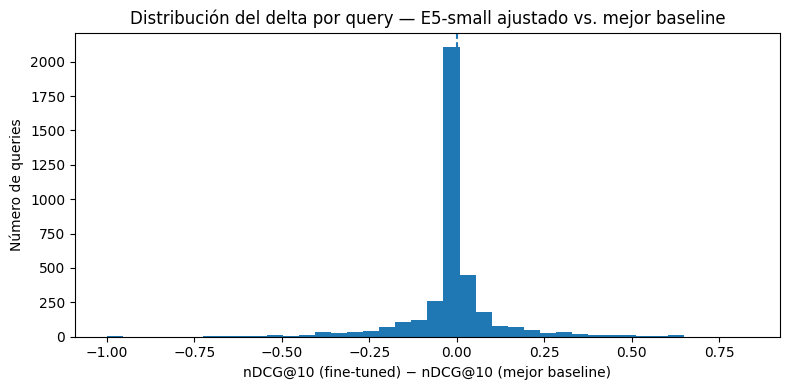

Delta promedio: -0.0090
Delta mediana : +0.0000
% de queries con mejora estricta (delta > 0): 29.3%


In [70]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(comparacion_q["delta_vs_mejor_baseline"], bins=40)
ax.axvline(0, linestyle="--")
ax.set_xlabel("nDCG@10 (fine-tuned) − nDCG@10 (mejor baseline)")
ax.set_ylabel("Número de queries")
ax.set_title("Distribución del delta por query — E5-small ajustado vs. mejor baseline")
plt.tight_layout()
plt.savefig("Resultados/distribucion_delta_ndcg.png", dpi=120)
plt.show()

print(f"Delta promedio: {comparacion_q['delta_vs_mejor_baseline'].mean():+.4f}")
print(f"Delta mediana : {comparacion_q['delta_vs_mejor_baseline'].median():+.4f}")
print(f"% de queries con mejora estricta (delta > 0): "
      f"{(comparacion_q['delta_vs_mejor_baseline'] > 0).mean() * 100:.1f}%")

## 4.9 · Hipótesis sobre los casos sin mejora *(completar tras ejecutar)*

> **Pendiente de completar por el equipo con los resultados reales de §4.7–§4.8.** No se
> rellena con una hipótesis genérica antes de ver los datos — eso violaría el punto de partida
> metodológico de esta sección (las métricas se definen antes de ver los resultados, pero la
> *lectura* de los resultados viene después de tenerlos).
>
> Guía para completar esta sección:
> - Inspeccionar manualmente 5–10 filas de `casos_sin_mejora` (§4.7): ¿son queries cortas?
>   ¿Marcas poco frecuentes en el train set? ¿Casos donde BM25 gana por coincidencia léxica
>   exacta que el encoder generaliza de más?
> - Cruzar `casos_sin_mejora` con la distribución de categorías/longitud de query en
>   `df_train` para ver si hay un patrón sistemático vs. ruido aleatorio.
> - Documentar aquí la hipótesis con 2-3 ejemplos concretos de `query` / `product_title`
>   citados desde `casos_sin_mejora`.

## 4.10 · Lectura honesta del delta *(completar tras ejecutar)*

> **Pendiente de completar por el equipo con los resultados reales de la tabla de §4.6.**
>
> Guía para completar esta sección:
> - ¿`E5-small congelado` superó a `BM25`? Si sí, el argumento de que el pre-entrenamiento del
>   encoder ya aporta señal semántica se fortalece (ver la nota del README sobre este punto).
> - ¿Cuánto mejoró `E5-small ajustado` sobre `E5-small congelado`? Ese delta es el efecto neto
>   del fine-tuning, aislado del efecto del pre-entrenamiento.
> - ¿El delta de nDCG@10 justifica el costo de memoria/latencia adicional frente a BM25?
> - Si se corrió la ablación opcional: ¿la mejora de `E5-base ajustado` sobre `E5-small
>   ajustado` justifica el costo de cómputo adicional (§1.5)?
> - Terminar con una recomendación explícita: ¿se adopta `E5-small ajustado` como motor de
>   scoring del sistema Digitdeck, o se necesita otra iteración antes de M2?


---

# Antes de entregar

Checklist final (`TODO.md`) — revisar manualmente antes de subir el notebook ejecutado:

- [ ] Releer el `README.md` de M1 y confirmar que cada criterio de la tabla tiene evidencia
      verificable en el repo (no solo texto afirmando que se cumplió).
- [ ] Confirmar que el notebook está ejecutado con outputs visibles (celdas con resultado) —
      correr `Runtime → Run all` de punta a punta antes de exportar/subir.
- [ ] Confirmar que el análisis de tokenizador sobre texto de dominio (§1.4) está incluido
      como evidencia del criterio 1.
- [ ] Revisar que los splits del dataset son reproducibles (§2.5–§2.6) y el script está
      versionado.
- [ ] Confirmar que la tabla de métricas (§4.6) incluye nDCG@10 para todas las variantes bajo
      las mismas condiciones de evaluación (`df_test_eval`, mismo `k=10`).
- [ ] Completar §4.9 y §4.10 con la lectura real de los resultados — no dejarlas en la guía
      de placeholder.
- [ ] Revisar que no se atribuyeron a la docente criterios, formatos o fechas que no han sido
      publicados oficialmente (las rúbricas detalladas aún no se han publicado — ver
      "Estado actual" en el `README.md`).
